# FINAL — Diffusion / DDPM per Emerging Jets

Questo notebook implementa il **Diffusion Model finale** usando i dataset aggregate creati dal preprocessing `FINAL`.

Input previsto:

```text
FINAL/processed/repr1_aggregate.npz
```

Schema dati:

```text
bkg_train  -> training QCD
bkg_eval   -> validation QCD + test QCD interno
sig        -> signal EJ
```

Se nel file è già presente un `bkg_test`, viene usato quello come test QCD.  
Altrimenti `bkg_eval` viene diviso in:

```text
bkg_val  -> early stopping
bkg_test -> ROC/AUC finale contro signal
```

Score di anomalia:

```text
score = denoising error
```

Il modello riceve una versione rumorosa del jet aggregato `x_t` e il timestep `t`, e impara a predire il rumore gaussiano aggiunto.


## 1. Import, seed e device

In [21]:
from pathlib import Path
import json
import copy
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Torch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Using device: cuda


## 2. Path e caricamento dataset aggregate

In [22]:
# come gli altri, cerca il percorso SE CREATO COME DETTO

CANDIDATE_BASES = [
    Path(".."),
    Path("."),
    Path("FINAL"),
]

PROCESSED_PATH = None

for base in CANDIDATE_BASES:
    candidate = base / "processed" / "repr1_aggregate.npz"
    if candidate.exists():
        PROCESSED_PATH = candidate
        PROJECT_BASE = base
        break

if PROCESSED_PATH is None:
    raise FileNotFoundError(
        "Non trovo repr1_aggregate.npz. "
        "Controlla che esista in FINAL/processed/repr1_aggregate.npz "
        "oppure modifica PROCESSED_PATH manualmente."
    )

OUTPUT_DIR = PROJECT_BASE / "outputs" / "diffusion"
PLOTS_DIR = OUTPUT_DIR / "plots"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_BASE:", PROJECT_BASE.resolve())
print("PROCESSED_PATH:", PROCESSED_PATH.resolve())
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())

data = np.load(PROCESSED_PATH, allow_pickle=True)
print("\nKeys in repr1_aggregate.npz:")
for k in data.keys():
    arr = data[k]
    print(f"  {k:35s} shape={arr.shape} dtype={arr.dtype}")

PROJECT_BASE: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL
PROCESSED_PATH: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\processed\repr1_aggregate.npz
OUTPUT_DIR: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\outputs\diffusion

Keys in repr1_aggregate.npz:
  bkg_train                           shape=(100000, 96) dtype=float32
  bkg_eval                            shape=(100000, 96) dtype=float32
  sig                                 shape=(61966, 96) dtype=float32
  feature_names                       shape=(96,) dtype=object
  norm_mean                           shape=(1, 96) dtype=float32
  norm_std                            shape=(1, 96) dtype=float32


## 3. Loader delle chiavi

In [23]:
def first_existing_key(data, candidates, required=True):
    for key in candidates:
        if key in data:
            return key
    if required:
        raise KeyError(
            "Nessuna delle chiavi candidate è presente: "
            + ", ".join(candidates)
            + "\nChiavi disponibili: "
            + ", ".join(data.keys())
        )
    return None


train_key = first_existing_key(
    data,
    [
        "X_agg_bkg_train",
        "bkg_train",
        "X_bkg_train",
        "X_train_background",
        "X_agg_train_background",
        "train_background",
        "X_train",
    ],
)

eval_key = first_existing_key(
    data,
    [
        "X_agg_bkg_eval",
        "bkg_eval",
        "X_bkg_eval",
        "X_eval_background",
        "X_agg_eval_background",
        "eval_background",
        "X_eval",
        "X_val",
    ],
)

sig_key = first_existing_key(
    data,
    [
        "X_agg_sig",
        "sig",
        "X_sig",
        "X_signal",
        "X_test_signal",
        "X_agg_test_signal",
        "test_signal",
    ],
)

feature_key = first_existing_key(
    data,
    [
        "aggregate_feature_names",
        "agg_feature_names",
        "feature_names",
        "X_agg_feature_names",
    ],
    required=False,
)

X_train_raw = np.asarray(data[train_key], dtype=np.float32)
X_eval_raw = np.asarray(data[eval_key], dtype=np.float32)
X_sig_raw = np.asarray(data[sig_key], dtype=np.float32)

# Uso direttamente il campione di evaluation QCD sia per validazione
# sia come background di confronto finale, come fatto per AE/VAE.
X_val_raw = X_eval_raw
X_bkg_test_raw = X_eval_raw.copy()

if feature_key is not None:
    aggregate_feature_names = [str(x) for x in data[feature_key].tolist()]
else:
    aggregate_feature_names = [f"f{i}" for i in range(X_train_raw.shape[1])]

print("\nSelected keys:")
print("train:", train_key, X_train_raw.shape)
print("eval:", eval_key, X_eval_raw.shape)
print("val:", X_val_raw.shape)
print("bkg_test: using eval copy", X_bkg_test_raw.shape)
print("signal:", sig_key, X_sig_raw.shape)
print("n features:", len(aggregate_feature_names))


Selected keys:
train: bkg_train (100000, 96)
eval: bkg_eval (100000, 96)
val: (100000, 96)
bkg_test: using eval copy (100000, 96)
signal: sig (61966, 96)
n features: 96


## 4. Anti-leakage check

In [24]:
FORBIDDEN_SUBSTRINGS = [
    "isDisplaced",
    "isTagged",
    "salt_pdisp",
    "displacedPtFraction",
    "flavour_label",
    "truthOriginLabel",
    "truthVertexIndex",
    "VSIVertexIndex",
    "truth_dark_pions",
    "truth_stable_non_geant",
    "eventNumber",
    "mcEventWeight",
    "averageInteractionsPerCrossing",
    "actualInteractionsPerCrossing",
    "nPrimaryVertices",
    "isRun3",
]

bad_features = []

for name in aggregate_feature_names:
    for bad in FORBIDDEN_SUBSTRINGS:
        if bad.lower() in name.lower():
            bad_features.append(name)

if bad_features:
    print("ERRORE: trovate feature potenzialmente leaky negli input aggregate:")
    for f in bad_features:
        print("  ", f)
    raise RuntimeError("Leakage check failed. Rimuovi queste feature dal preprocessing.")
else:
    print("Leakage check OK: nessuna feature vietata trovata negli input aggregate.")
#in realtà, avendolo costruito così non serve, ma visto che nei vecchi codici succedeva 
#di dimenticarla, meglio controllare ogni volta 

Leakage check OK: nessuna feature vietata trovata negli input aggregate.


## 5. Pulizia, robust scaling e clipping

In [25]:
#anche qui, dopo il preprocessing fatto bene ricontrollare non servirebbe
def finite_array(X, name):
    X = np.asarray(X, dtype=np.float32)
    finite = np.isfinite(X)
    if not finite.all():
        print(f"[WARN] {name}: sostituisco NaN/inf con 0. Non-finite:", np.sum(~finite))
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    return X


X_train_raw = finite_array(X_train_raw, "X_train_raw")
X_val_raw = finite_array(X_val_raw, "X_val_raw")
X_bkg_test_raw = finite_array(X_bkg_test_raw, "X_bkg_test_raw")
X_sig_raw = finite_array(X_sig_raw, "X_sig_raw")


class RobustClipScaler:
    def __init__(self, clip_value=8.0, eps=1e-6):
        self.clip_value = clip_value
        self.eps = eps
        self.center = None
        self.scale = None

    def fit(self, X):
        self.center = np.median(X, axis=0, keepdims=True)
        q25 = np.percentile(X, 25, axis=0, keepdims=True)
        q75 = np.percentile(X, 75, axis=0, keepdims=True)
        self.scale = np.maximum(q75 - q25, self.eps)
        return self

    def transform(self, X):
        Xn = (X - self.center) / self.scale
        Xn = np.nan_to_num(Xn, nan=0.0, posinf=0.0, neginf=0.0)
        Xn = np.clip(Xn, -self.clip_value, self.clip_value)
        return Xn.astype(np.float32)

    def state_dict(self):
        return {
            "clip_value": float(self.clip_value),
            "eps": float(self.eps),
            "center": self.center.reshape(-1).tolist(),
            "scale": self.scale.reshape(-1).tolist(),
        }

#togliamo valori estremi, nel diffusion danno problemi
CLIP_VALUE = 8.0

scaler = RobustClipScaler(clip_value=CLIP_VALUE)
scaler.fit(X_train_raw)

X_train = scaler.transform(X_train_raw)
X_val = scaler.transform(X_val_raw)
X_bkg_test = scaler.transform(X_bkg_test_raw)
X_sig = scaler.transform(X_sig_raw)

print("After robust scaling + clipping:")
for name, X in [
    ("train", X_train),
    ("val", X_val),
    ("bkg_test", X_bkg_test),
    ("signal", X_sig),
]:
    print(
        f"{name:10s} shape={X.shape} "
        f"mean={X.mean():.4f} std={X.std():.4f} "
        f"clip_frac={np.mean((X <= -CLIP_VALUE) | (X >= CLIP_VALUE)):.5f}"
    )

input_dim = X_train.shape[1]
print("input_dim:", input_dim)

with open(OUTPUT_DIR / "aggregate_diffusion_scaler.json", "w") as f:
    json.dump(scaler.state_dict(), f, indent=2)

print("Saved scaler:", OUTPUT_DIR / "aggregate_diffusion_scaler.json")

After robust scaling + clipping:
train      shape=(100000, 96) mean=0.0088 std=1.1453 clip_frac=0.00944
val        shape=(100000, 96) mean=0.0068 std=1.1431 clip_frac=0.00942
bkg_test   shape=(100000, 96) mean=0.0068 std=1.1431 clip_frac=0.00942
signal     shape=(61966, 96) mean=-0.0578 std=1.6772 clip_frac=0.02470
input_dim: 96
Saved scaler: ..\outputs\diffusion\aggregate_diffusion_scaler.json


## 6. Dataset e DataLoader

In [26]:
class DiffusionDataset(Dataset):
    def __init__(self, X):
        self.X = torch.from_numpy(np.asarray(X, dtype=np.float32))

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx]


BATCH_SIZE = 1024

train_loader = DataLoader(
    DiffusionDataset(X_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    DiffusionDataset(X_val),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 98
Val batches: 98


## 7. Diffusion schedule

In [27]:
# Tabular DDPM schedule (Denoising Diffusion Probabilistic Model)
# T=200 è un buon compromesso tra stabilità e costo. T è il numero di step di diffusione

T = 200
# Beta controlla quanta noise aggiungo a ogni step.
# Qui parte molto piccolo e cresce linearmente fino a 2e-2.
BETA_START = 1e-4
BETA_END = 2e-2

betas = torch.linspace(BETA_START, BETA_END, T, dtype=torch.float32, device=device)
alphas = 1.0 - betas

# Mi dice quanta informazione dell'input originale resta dopo t step di diffusione.
alpha_bars = torch.cumprod(alphas, dim=0)

snr = alpha_bars / (1.0 - alpha_bars)

print("T:", T)
print("beta_start:", BETA_START)
print("beta_end:", BETA_END)
print("alpha_bar first/last:", alpha_bars[0].item(), alpha_bars[-1].item())
print("SNR first/last:", snr[0].item(), snr[-1].item())


def q_sample(x0, t, noise=None):
    #rumore gaussiano, se non decido io degli step e etc mette questo
    if noise is None:
        noise = torch.randn_like(x0)

    a_bar = alpha_bars[t].unsqueeze(1)
    #crea il dato con il rumore, ovviamente un mix tra originale e diffusione
    xt = torch.sqrt(a_bar) * x0 + torch.sqrt(1.0 - a_bar) * noise

    return xt, noise

T: 200
beta_start: 0.0001
beta_end: 0.02
alpha_bar first/last: 0.9998999834060669 0.132182776927948
SNR first/last: 9997.3408203125 0.1523163765668869


## 8. Modello denoiser residual MLP

In [28]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.emb_dim = emb_dim

    def forward(self, t):
        # Converto lo step temporale t in un vettore di embedding.
        # Serve perché il modello deve sapere a quale livello di rumore si trova.
        half_dim = self.emb_dim // 2
        device_t = t.device
        # Creo frequenze diverse, come nei positional encoding dei Transformer.
        freqs = torch.exp(
            -math.log(10000) * torch.arange(0, half_dim, device=device_t).float() / max(half_dim - 1, 1)
        )
 # Combino il tempo t con le frequenze e uso seno/coseno per ottenere una rappresentazione continua dello step di diffusione.
        args = t.float().unsqueeze(1) * freqs.unsqueeze(0)
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=1)

        if self.emb_dim % 2 == 1:
            emb = torch.cat([emb, torch.zeros_like(emb[:, :1])], dim=1)

        return emb


class ResidualBlock(nn.Module):
    def __init__(self, hidden_dim, dropout=0.05):
        super().__init__()
 # Blocco fully-connected con normalizzazione, attivazione e dropout.
# È residuale perché l'output verrà sommato all'input.
        self.block = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Dropout(dropout),
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

    def forward(self, x):
        return x + self.block(x)


class ResidualTabularDenoiser(nn.Module):
    def __init__(
        self,
        input_dim,
        time_emb_dim=64,
        hidden_dim=384,
        n_blocks=4,
        dropout=0.05,
    ):
        super().__init__()
 # Embedding dello step di diffusione.
# Il denoiser deve sapere quanto rumore è stato aggiunto al dato.
        self.time_embedding = SinusoidalTimeEmbedding(time_emb_dim)

        self.time_mlp = nn.Sequential(
            nn.Linear(time_emb_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self.input_proj = nn.Linear(input_dim, hidden_dim)

        self.blocks = nn.ModuleList([
            ResidualBlock(hidden_dim, dropout=dropout)
            for _ in range(n_blocks)
        ])
# Riporto l'output alla dimensione originale delle feature.
#rappresenta tipicamente il rumore predetto.
        self.output = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, input_dim),
        )

    def forward(self, xt, t):
        t_h = self.time_mlp(self.time_embedding(t))
        h = self.input_proj(xt) + t_h

        for block in self.blocks:
            h = block(h)

        return self.output(h)

## 8.1 Quick hyperparameter tuning Diffusion

Questa sezione applica lo stesso ragionamento usato per AE/VAE: provo alcune combinazioni di iperparametri usando **solo QCD train/validation**.  
Il segnale EJ non viene mai usato per scegliere la configurazione migliore.


In [29]:
# ============================================================
# Quick hyperparameter tuning — Diffusion / DDPM
# ============================================================
# Criterio:
# - uso solo QCD train/validation;
# - non uso mai il segnale EJ;
# - alleno pochi epoch su un subset;
# - scelgo la configurazione con validation diffusion loss più bassa;
# - penalizzo leggermente overfitting train/validation.
#
# Iperparametri testati:
# - hidden_dim: larghezza della rete;
# - n_blocks: profondità;
# - dropout;
# - time_emb_dim;
# - T: numero di timestep diffusion;
# - beta_end: quantità massima di rumore nella schedule;
# - learning rate;
# - weight decay;
# - batch size.
# ============================================================

import gc

RUN_DIFFUSION_HPARAM_TUNING = True

TUNE_MAX_TRAIN = 10_000
TUNE_MAX_VAL = 8_000
TUNE_EPOCHS = 14
TUNE_PATIENCE = 4


CANDIDATE_CONFIGS = [
    {
        "time_emb_dim": 32,
        "hidden_dim": 256,
        "n_blocks": 3,
        "dropout": 0.03,
        "T": 100,
        "beta_start": 1e-4,
        "beta_end": 1.5e-2,
        "lr": 1.2e-4,
        "weight_decay": 1e-5,
        "batch_size": 1024,
    },
    {
        "time_emb_dim": 64,
        "hidden_dim": 384,
        "n_blocks": 4,
        "dropout": 0.05,
        "T": 200,
        "beta_start": 1e-4,
        "beta_end": 2.0e-2,
        "lr": 1.0e-4,
        "weight_decay": 1e-5,
        "batch_size": 1024,
    },
    {
        "time_emb_dim": 64,
        "hidden_dim": 512,
        "n_blocks": 4,
        "dropout": 0.07,
        "T": 200,
        "beta_start": 1e-4,
        "beta_end": 2.0e-2,
        "lr": 8e-5,
        "weight_decay": 2e-5,
        "batch_size": 768,
    },
    {
        "time_emb_dim": 96,
        "hidden_dim": 512,
        "n_blocks": 5,
        "dropout": 0.08,
        "T": 200,
        "beta_start": 1e-4,
        "beta_end": 2.5e-2,
        "lr": 7e-5,
        "weight_decay": 2e-5,
        "batch_size": 768,
    },
    {
        "time_emb_dim": 64,
        "hidden_dim": 384,
        "n_blocks": 5,
        "dropout": 0.10,
        "T": 300,
        "beta_start": 1e-4,
        "beta_end": 2.0e-2,
        "lr": 7e-5,
        "weight_decay": 3e-5,
        "batch_size": 768,
    },
    {
        "time_emb_dim": 128,
        "hidden_dim": 640,
        "n_blocks": 5,
        "dropout": 0.10,
        "T": 300,
        "beta_start": 1e-4,
        "beta_end": 2.5e-2,
        "lr": 5e-5,
        "weight_decay": 5e-5,
        "batch_size": 512,
    },
    {
        "time_emb_dim": 96,
        "hidden_dim": 512,
        "n_blocks": 6,
        "dropout": 0.12,
        "T": 300,
        "beta_start": 1e-4,
        "beta_end": 3.0e-2,
        "lr": 5e-5,
        "weight_decay": 5e-5,
        "batch_size": 512,
    },
]


def _subsample(X, max_n, seed):
    if len(X) <= max_n:
        return X
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), size=max_n, replace=False)
    return X[idx]


X_tune_train = _subsample(X_train, TUNE_MAX_TRAIN, SEED)
X_tune_val = _subsample(X_val, TUNE_MAX_VAL, SEED + 1)

print("Tuning train:", X_tune_train.shape)
print("Tuning val:", X_tune_val.shape)


def make_tune_loader(X, batch_size, shuffle=False):
    return DataLoader(
        DiffusionDataset(X),
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )


def make_local_schedule(T_local, beta_start_local, beta_end_local):
    betas_local = torch.linspace(
        beta_start_local,
        beta_end_local,
        int(T_local),
        dtype=torch.float32,
        device=device,
    )
    alphas_local = 1.0 - betas_local
    alpha_bars_local = torch.cumprod(alphas_local, dim=0)
    return betas_local, alphas_local, alpha_bars_local


def q_sample_local(x0, t, alpha_bars_local, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)

    a_bar = alpha_bars_local[t].unsqueeze(1)
    xt = torch.sqrt(a_bar) * x0 + torch.sqrt(1.0 - a_bar) * noise
    return xt, noise


def diffusion_loss_local(model, x0, T_local, alpha_bars_local):
    B = x0.shape[0]

    t = torch.randint(
        0,
        int(T_local),
        (B,),
        device=x0.device,
        dtype=torch.long,
    )

    noise = torch.randn_like(x0)
    xt, noise = q_sample_local(x0, t, alpha_bars_local, noise=noise)

    pred_noise = model(xt, t)

    return torch.mean((pred_noise - noise) ** 2)


@torch.no_grad()
def eval_diffusion_loss_local(model, loader, T_local, alpha_bars_local):
    model.eval()

    total = 0.0
    n = 0

    for X_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)

        loss = diffusion_loss_local(
            model,
            X_batch,
            T_local,
            alpha_bars_local,
        )

        total += loss.item() * X_batch.shape[0]
        n += X_batch.shape[0]

    return total / max(n, 1)


def tune_one_diffusion_config(cfg, config_id):
    print("\n" + "=" * 90)
    print(f"DIFFUSION CONFIG {config_id}/{len(CANDIDATE_CONFIGS)}")
    print(cfg)

    train_l = make_tune_loader(
        X_tune_train,
        batch_size=int(cfg["batch_size"]),
        shuffle=True,
    )

    val_l = make_tune_loader(
        X_tune_val,
        batch_size=int(cfg["batch_size"]),
        shuffle=False,
    )

    _, _, alpha_bars_local = make_local_schedule(
        cfg["T"],
        cfg["beta_start"],
        cfg["beta_end"],
    )

    model_tune = ResidualTabularDenoiser(
        input_dim=input_dim,
        time_emb_dim=int(cfg["time_emb_dim"]),
        hidden_dim=int(cfg["hidden_dim"]),
        n_blocks=int(cfg["n_blocks"]),
        dropout=float(cfg["dropout"]),
    ).to(device)

    n_params = sum(p.numel() for p in model_tune.parameters() if p.requires_grad)

    optimizer_tune = torch.optim.AdamW(
        model_tune.parameters(),
        lr=float(cfg["lr"]),
        weight_decay=float(cfg["weight_decay"]),
    )

    scheduler_tune = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_tune,
        mode="min",
        factor=0.5,
        patience=2,
    )

    best_val = np.inf
    best_state = None
    best_epoch = -1
    patience_counter = 0

    for epoch in range(1, TUNE_EPOCHS + 1):
        model_tune.train()

        train_losses = []

        for X_batch in train_l:
            X_batch = X_batch.to(device, non_blocking=True)

            optimizer_tune.zero_grad()

            loss = diffusion_loss_local(
                model_tune,
                X_batch,
                int(cfg["T"]),
                alpha_bars_local,
            )

            if not torch.isfinite(loss):
                raise RuntimeError("Diffusion tuning loss non finita")

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_tune.parameters(), max_norm=5.0)
            optimizer_tune.step()

            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))

        val_loss = eval_diffusion_loss_local(
            model_tune,
            val_l,
            int(cfg["T"]),
            alpha_bars_local,
        )

        scheduler_tune.step(val_loss)

        print(
            f"epoch {epoch:02d}/{TUNE_EPOCHS} | "
            f"train={train_loss:.6f} | "
            f"val={val_loss:.6f} | "
            f"best={best_val:.6f}"
        )

        if val_loss < best_val:
            best_val = val_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model_tune.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= TUNE_PATIENCE:
            print("early stopping tuning")
            break

    if best_state is not None:
        model_tune.load_state_dict(best_state)

    train_loss_final = eval_diffusion_loss_local(
        model_tune,
        train_l,
        int(cfg["T"]),
        alpha_bars_local,
    )

    val_loss_final = eval_diffusion_loss_local(
        model_tune,
        val_l,
        int(cfg["T"]),
        alpha_bars_local,
    )

    gap = max(0.0, val_loss_final - train_loss_final)

    # Score di selezione:
    # - validation loss più bassa è meglio;
    # - penalizzo leggermente gap train/val.
    selection_score = best_val + 0.30 * gap

    result = {
        "config_id": config_id,
        **cfg,
        "n_params": int(n_params),
        "best_epoch": int(best_epoch),
        "train_loss": float(train_loss_final),
        "val_loss": float(val_loss_final),
        "generalization_gap": float(gap),
        "selection_score": float(selection_score),
    }

    del model_tune
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result


if RUN_DIFFUSION_HPARAM_TUNING:
    tuning_rows = []

    for i, cfg in enumerate(CANDIDATE_CONFIGS, start=1):
        try:
            tuning_rows.append(tune_one_diffusion_config(cfg, i))
        except RuntimeError as e:
            print(f"[SKIP CONFIG {i}] RuntimeError:", e)
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    diffusion_tuning_results_df = pd.DataFrame(tuning_rows)

    diffusion_tuning_results_df = diffusion_tuning_results_df.sort_values(
        "selection_score",
        ascending=True,
    ).reset_index(drop=True)

    display(diffusion_tuning_results_df)

    diffusion_tuning_results_df.to_csv(
        OUTPUT_DIR / "diffusion_hparam_tuning.csv",
        index=False,
    )

    print("Saved:", OUTPUT_DIR / "diffusion_hparam_tuning.csv")

    BEST_DIFFUSION_CONFIG = diffusion_tuning_results_df.iloc[0].to_dict()

else:
    BEST_DIFFUSION_CONFIG = {
        "time_emb_dim": 64,
        "hidden_dim": 384,
        "n_blocks": 4,
        "dropout": 0.05,
        "T": 200,
        "beta_start": 1e-4,
        "beta_end": 2e-2,
        "lr": 1e-4,
        "weight_decay": 1e-5,
        "batch_size": 1024,
    }

print("\n" + "=" * 90)
print("BEST DIFFUSION CONFIG")
print(BEST_DIFFUSION_CONFIG)

# Imposto le variabili globali che verranno usate dal training finale.
TIME_EMB_DIM = int(BEST_DIFFUSION_CONFIG["time_emb_dim"])
HIDDEN_DIM = int(BEST_DIFFUSION_CONFIG["hidden_dim"])
N_BLOCKS = int(BEST_DIFFUSION_CONFIG["n_blocks"])
DROPOUT = float(BEST_DIFFUSION_CONFIG["dropout"])

T = int(BEST_DIFFUSION_CONFIG["T"])
BETA_START = float(BEST_DIFFUSION_CONFIG["beta_start"])
BETA_END = float(BEST_DIFFUSION_CONFIG["beta_end"])

LR = float(BEST_DIFFUSION_CONFIG["lr"])
WEIGHT_DECAY = float(BEST_DIFFUSION_CONFIG["weight_decay"])
BATCH_SIZE = int(BEST_DIFFUSION_CONFIG["batch_size"])

# Training finale: più lungo del tuning.
N_EPOCHS = 120
PATIENCE = 18

print("\nIperparametri finali impostati:")
print("TIME_EMB_DIM =", TIME_EMB_DIM)
print("HIDDEN_DIM   =", HIDDEN_DIM)
print("N_BLOCKS     =", N_BLOCKS)
print("DROPOUT      =", DROPOUT)
print("T            =", T)
print("BETA_START   =", BETA_START)
print("BETA_END     =", BETA_END)
print("LR           =", LR)
print("WEIGHT_DECAY =", WEIGHT_DECAY)
print("BATCH_SIZE   =", BATCH_SIZE)
print("N_EPOCHS     =", N_EPOCHS)
print("PATIENCE     =", PATIENCE)

Tuning train: (10000, 96)
Tuning val: (8000, 96)

DIFFUSION CONFIG 1/7
{'time_emb_dim': 32, 'hidden_dim': 256, 'n_blocks': 3, 'dropout': 0.03, 'T': 100, 'beta_start': 0.0001, 'beta_end': 0.015, 'lr': 0.00012, 'weight_decay': 1e-05, 'batch_size': 1024}
epoch 01/14 | train=1.083578 | val=1.044748 | best=inf
epoch 02/14 | train=1.031300 | val=1.009707 | best=1.044748
epoch 03/14 | train=1.000440 | val=0.986485 | best=1.009707
epoch 04/14 | train=0.985678 | val=0.976228 | best=0.986485
epoch 05/14 | train=0.972306 | val=0.962363 | best=0.976228
epoch 06/14 | train=0.958254 | val=0.952177 | best=0.962363
epoch 07/14 | train=0.946429 | val=0.936623 | best=0.952177
epoch 08/14 | train=0.933312 | val=0.923659 | best=0.936623
epoch 09/14 | train=0.917409 | val=0.906008 | best=0.923659
epoch 10/14 | train=0.904998 | val=0.892545 | best=0.906008
epoch 11/14 | train=0.888328 | val=0.878624 | best=0.892545
epoch 12/14 | train=0.877433 | val=0.865454 | best=0.878624
epoch 13/14 | train=0.862639 | va

,config_id,time_emb_dim,hidden_dim,n_blocks,dropout,T,beta_start,beta_end,lr,weight_decay,batch_size,n_params,best_epoch,train_loss,val_loss,generalization_gap,selection_score
0,6,128,640,5,0.10,300,0.0001,0.025,0.00005,0.00005,512,4732896,14,0.440294,0.446913,0.006619,0.446959
1,7,96,512,6,0.12,300,0.0001,0.030,0.00005,0.00005,512,3576416,14,0.477263,0.478631,0.001368,0.479288
2,4,96,512,5,0.08,200,0.0001,0.025,0.00007,0.00002,768,3049056,14,0.591956,0.588637,0.000000,0.588970
3,3,64,512,4,0.07,200,0.0001,0.020,0.00008,0.00002,768,2505312,14,0.613694,0.612831,0.000000,0.614811
4,2,64,384,4,0.05,200,0.0001,0.020,0.00010,0.00001,1024,1436640,14,0.637882,0.639868,0.001986,0.637789
5,5,64,384,5,0.10,300,0.0001,0.020,0.00007,0.00003,768,1733856,14,0.674327,0.672498,0.000000,0.669105
6,1,32,256,3,0.03,100,0.0001,0.015,0.00012,0.00001,1024,522080,14,0.835219,0.838019,0.002799,0.835262


Saved: ..\outputs\diffusion\diffusion_hparam_tuning.csv

BEST DIFFUSION CONFIG
{'config_id': 6.0, 'time_emb_dim': 128.0, 'hidden_dim': 640.0, 'n_blocks': 5.0, 'dropout': 0.1, 'T': 300.0, 'beta_start': 0.0001, 'beta_end': 0.025, 'lr': 5e-05, 'weight_decay': 5e-05, 'batch_size': 512.0, 'n_params': 4732896.0, 'best_epoch': 14.0, 'train_loss': 0.4402941645145416, 'val_loss': 0.44691335916519165, 'generalization_gap': 0.006619194650650029, 'selection_score': 0.4469589773130417}

Iperparametri finali impostati:
TIME_EMB_DIM = 128
HIDDEN_DIM   = 640
N_BLOCKS     = 5
DROPOUT      = 0.1
T            = 300
BETA_START   = 0.0001
BETA_END     = 0.025
LR           = 5e-05
WEIGHT_DECAY = 5e-05
BATCH_SIZE   = 512
N_EPOCHS     = 120
PATIENCE     = 18


## 8.2 Plot tuning Diffusion in stile gomito

Questi plot riassumono l'effetto dei principali iperparametri.  
Il criterio è sempre: **più basso è meglio**.


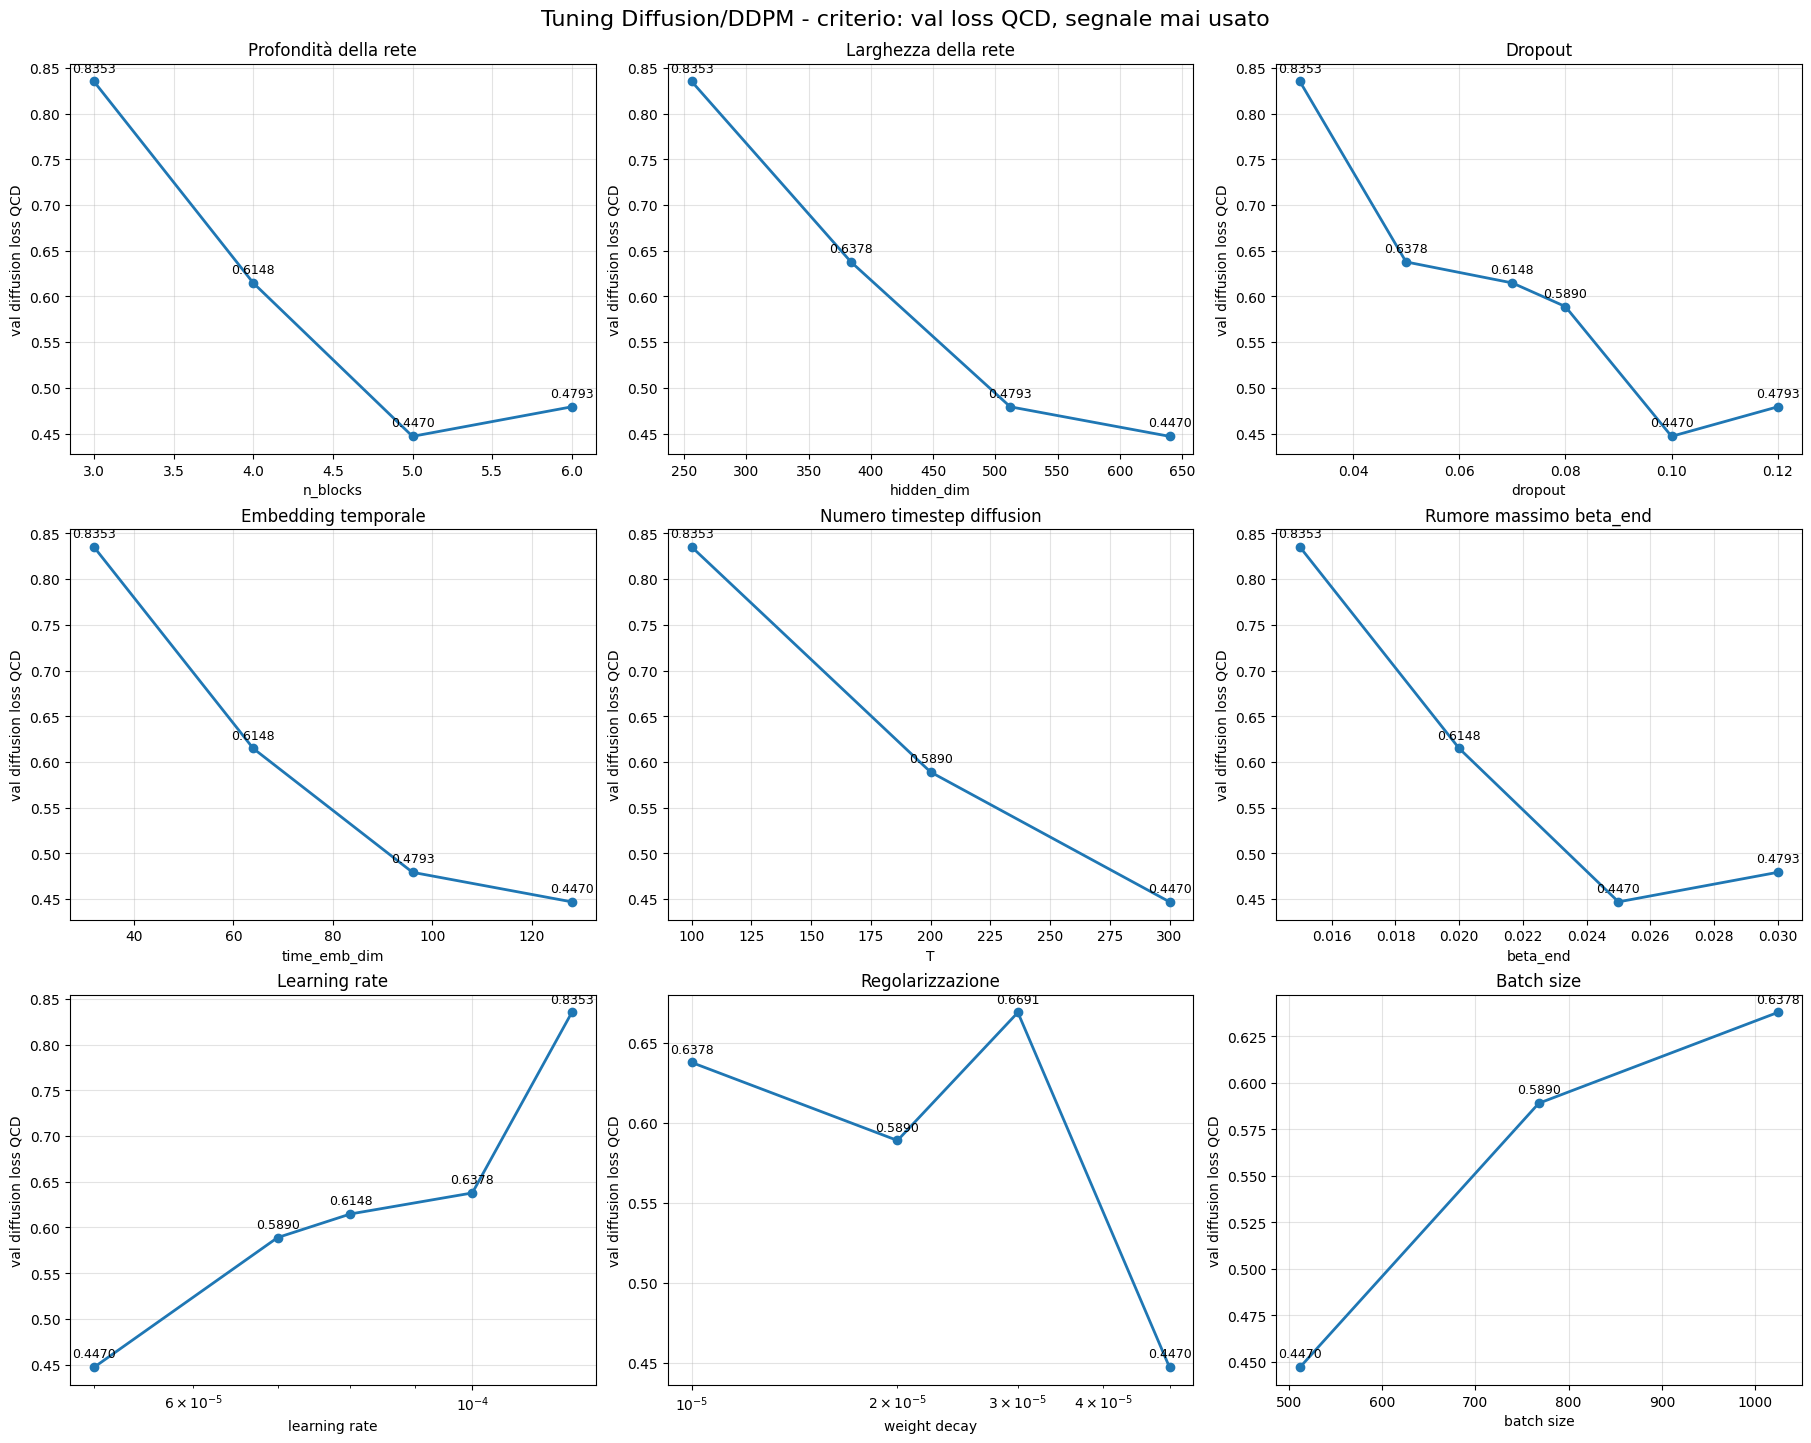

Salvato: ..\outputs\diffusion\plots\diffusion_hparam_elbow_plots.png


,config_id,time_emb_dim,hidden_dim,n_blocks,dropout,T,beta_start,beta_end,lr,weight_decay,batch_size,n_params,best_epoch,train_loss,val_loss,generalization_gap,selection_score
0,6,128,640,5,0.10,300,0.0001,0.025,0.00005,0.00005,512,4732896,14,0.440294,0.446913,0.006619,0.446959
1,7,96,512,6,0.12,300,0.0001,0.030,0.00005,0.00005,512,3576416,14,0.477263,0.478631,0.001368,0.479288
2,4,96,512,5,0.08,200,0.0001,0.025,0.00007,0.00002,768,3049056,14,0.591956,0.588637,0.000000,0.588970
3,3,64,512,4,0.07,200,0.0001,0.020,0.00008,0.00002,768,2505312,14,0.613694,0.612831,0.000000,0.614811
4,2,64,384,4,0.05,200,0.0001,0.020,0.00010,0.00001,1024,1436640,14,0.637882,0.639868,0.001986,0.637789
5,5,64,384,5,0.10,300,0.0001,0.020,0.00007,0.00003,768,1733856,14,0.674327,0.672498,0.000000,0.669105
6,1,32,256,3,0.03,100,0.0001,0.015,0.00012,0.00001,1024,522080,14,0.835219,0.838019,0.002799,0.835262


In [30]:
# ============================================================
# Plot tuning Diffusion 
# ============================================================

try:
    df_diff_tune = diffusion_tuning_results_df.copy()
except NameError:
    df_diff_tune = pd.read_csv(OUTPUT_DIR / "diffusion_hparam_tuning.csv")

Y_COL = "selection_score"
Y_LABEL = "val diffusion loss QCD"

def best_by_param(data, param):
    return (
        data
        .groupby(param, as_index=False)[Y_COL]
        .min()
        .sort_values(param)
        .reset_index(drop=True)
    )

def plot_line_with_labels(ax, x, y, xlabel, title, logx=False):
    ax.plot(x, y, marker="o", linewidth=2)

    for xi, yi in zip(x, y):
        ax.annotate(
            f"{yi:.4f}",
            xy=(xi, yi),
            xytext=(0, 7),
            textcoords="offset points",
            ha="center",
            fontsize=9,
        )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(Y_LABEL)
    ax.set_title(title)
    ax.grid(True, alpha=0.35)

    if logx:
        ax.set_xscale("log")

fig, axes = plt.subplots(
    3,
    3,
    figsize=(18, 14),
    constrained_layout=True,
)

axes = axes.flatten()

fig.suptitle(
    "Tuning Diffusion/DDPM - criterio: val loss QCD, segnale mai usato",
    fontsize=16,
    y=1.02,
)

for ax, param, xlabel, title, logx in [
    (axes[0], "n_blocks", "n_blocks", "Profondità della rete", False),
    (axes[1], "hidden_dim", "hidden_dim", "Larghezza della rete", False),
    (axes[2], "dropout", "dropout", "Dropout", False),

    (axes[3], "time_emb_dim", "time_emb_dim", "Embedding temporale", False),
    (axes[4], "T", "T", "Numero timestep diffusion", False),
    (axes[5], "beta_end", "beta_end", "Rumore massimo beta_end", False),

    (axes[6], "lr", "learning rate", "Learning rate", True),
    (axes[7], "weight_decay", "weight decay", "Regolarizzazione", True),
    (axes[8], "batch_size", "batch size", "Batch size", False),
]:
    g = best_by_param(df_diff_tune, param)

    plot_line_with_labels(
        ax,
        g[param],
        g[Y_COL],
        xlabel,
        title,
        logx=logx,
    )
out_path = PLOTS_DIR / "diffusion_hparam_elbow_plots.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()

print("Salvato:", out_path)
display(df_diff_tune.sort_values("selection_score").reset_index(drop=True))

## 9. Training

In [31]:
# ============================================================
# Creazione modello finale usando la configurazione scelta dal tuning
# ============================================================


if "BEST_DIFFUSION_CONFIG" in globals():
    TIME_EMB_DIM = int(BEST_DIFFUSION_CONFIG["time_emb_dim"])
    HIDDEN_DIM = int(BEST_DIFFUSION_CONFIG["hidden_dim"])
    N_BLOCKS = int(BEST_DIFFUSION_CONFIG["n_blocks"])
    DROPOUT = float(BEST_DIFFUSION_CONFIG["dropout"])

    T = int(BEST_DIFFUSION_CONFIG["T"])
    BETA_START = float(BEST_DIFFUSION_CONFIG["beta_start"])
    BETA_END = float(BEST_DIFFUSION_CONFIG["beta_end"])

    LR = float(BEST_DIFFUSION_CONFIG["lr"])
    WEIGHT_DECAY = float(BEST_DIFFUSION_CONFIG["weight_decay"])
    BATCH_SIZE = int(BEST_DIFFUSION_CONFIG["batch_size"])

    N_EPOCHS = 120
    PATIENCE = 18

    print("Uso configurazione scelta dal tuning.")
else:
    TIME_EMB_DIM = 64
    HIDDEN_DIM = 384
    N_BLOCKS = 4
    DROPOUT = 0.05

    T = 200
    BETA_START = 1e-4
    BETA_END = 2e-2

    LR = 1e-4
    WEIGHT_DECAY = 1e-5

    BATCH_SIZE = 1024
    N_EPOCHS = 120
    PATIENCE = 18

    print("BEST_DIFFUSION_CONFIG non trovata: uso configurazione standard.")

# Ricostruisco la schedule globale con i valori finali.
# Questo è importante perché il tuning può aver cambiato T o beta_end.
betas = torch.linspace(BETA_START, BETA_END, T, dtype=torch.float32, device=device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)
snr = alpha_bars / (1.0 - alpha_bars)

def q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)

    a_bar = alpha_bars[t].unsqueeze(1)
    xt = torch.sqrt(a_bar) * x0 + torch.sqrt(1.0 - a_bar) * noise

    return xt, noise

# Ricreo i DataLoader finali con il batch size scelto dal tuning.
train_loader = DataLoader(
    DiffusionDataset(X_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    DiffusionDataset(X_val),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

model = ResidualTabularDenoiser(
    input_dim=input_dim,
    time_emb_dim=TIME_EMB_DIM,
    hidden_dim=HIDDEN_DIM,
    n_blocks=N_BLOCKS,
    dropout=DROPOUT,
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=6,
)

print(model)
print("Parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))
print()
print("Final diffusion config:")
print("TIME_EMB_DIM =", TIME_EMB_DIM)
print("HIDDEN_DIM   =", HIDDEN_DIM)
print("N_BLOCKS     =", N_BLOCKS)
print("DROPOUT      =", DROPOUT)
print("T            =", T)
print("BETA_START   =", BETA_START)
print("BETA_END     =", BETA_END)
print("LR           =", LR)
print("WEIGHT_DECAY =", WEIGHT_DECAY)
print("BATCH_SIZE   =", BATCH_SIZE)
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Uso configurazione scelta dal tuning.
ResidualTabularDenoiser(
  (time_embedding): SinusoidalTimeEmbedding()
  (time_mlp): Sequential(
    (0): Linear(in_features=128, out_features=640, bias=True)
    (1): SiLU()
    (2): Linear(in_features=640, out_features=640, bias=True)
  )
  (input_proj): Linear(in_features=96, out_features=640, bias=True)
  (blocks): ModuleList(
    (0-4): 5 x ResidualBlock(
      (block): Sequential(
        (0): LayerNorm((640,), eps=1e-05, elementwise_affine=True)
        (1): SiLU()
        (2): Linear(in_features=640, out_features=640, bias=True)
        (3): Dropout(p=0.1, inplace=False)
        (4): LayerNorm((640,), eps=1e-05, elementwise_affine=True)
        (5): SiLU()
        (6): Linear(in_features=640, out_features=640, bias=True)
      )
    )
  )
  (output): Sequential(
    (0): LayerNorm((640,), eps=1e-05, elementwise_affine=True)
    (1): SiLU()
    (2): Linear(in_features=640, out_features=96, bias=True)
  )
)
Parameters: 4732896

Final diffusio

In [32]:
def diffusion_loss(model, x0):
     # Prendo la dimensione del batch.
    B = x0.shape[0]
    # Per ogni evento scelgo uno step di diffusione casuale così il modello impara a denoisare dati con livelli di rumore diversi.
    t = torch.randint(0, T, (B,), device=x0.device, dtype=torch.long)
    # Rumore gaussiano che verrà aggiunto ai dati originali.
    noise = torch.randn_like(x0)
    # Creo la versione rumorosa xt del dato originale x0.
    xt, noise = q_sample(x0, t, noise=noise)
    # Il modello riceve xt e lo step t, e prova a predire il rumore aggiunto.
    pred_noise = model(xt, t)
    # Loss del diffusion: errore quadratico medio tra rumore vero e rumore predetto.
    return torch.mean((pred_noise - noise) ** 2)


def evaluate_diffusion_loss(model, loader):
    model.eval()

    total_loss = 0.0
    total_items = 0

    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            loss = diffusion_loss(model, X_batch)

            total_loss += loss.item() * X_batch.shape[0]
            total_items += X_batch.shape[0]

    return total_loss / max(total_items, 1)


train_history = []
val_history = []
lr_history = []

best_val = np.inf
best_epoch = -1
best_state = None
epochs_no_improve = 0

for epoch in range(N_EPOCHS):
    model.train()

    total_loss = 0.0
    total_items = 0

    for X_batch in train_loader:
        X_batch = X_batch.to(device, non_blocking=True)

        optimizer.zero_grad()

        loss = diffusion_loss(model, X_batch)
# Controllo di sicurezza: se la loss diventa NaN o infinita, fermo tutto

        if not torch.isfinite(loss):
            raise RuntimeError("Loss non finita.")

        loss.backward()
        # Limito la norma dei gradienti
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        total_loss += loss.item() * X_batch.shape[0]
        total_items += X_batch.shape[0]
# Loss media di training e validation per questa epoca
    train_loss = total_loss / max(total_items, 1)
    val_loss = evaluate_diffusion_loss(model, val_loader)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    train_history.append(train_loss)
    val_history.append(val_loss)
    lr_history.append(current_lr)

    improved = val_loss < best_val

    if improved:
        best_val = val_loss
        best_epoch = epoch + 1
        best_state = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    print(
        f"Epoch {epoch+1:03d}/{N_EPOCHS} | "
        f"train loss={train_loss:.6f} | "
        f"val loss={val_loss:.6f} | "
        f"best={best_val:.6f} @ {best_epoch} | "
        f"lr={current_lr:.2e}"
    )
# Early stopping: se la validation non migliora per troppe epoche, fermo il training.
    if epochs_no_improve >= PATIENCE:
        print("Early stopping.")
        break

if best_state is not None:
    model.load_state_dict(best_state)
    print(f"Loaded best model from epoch {best_epoch} with val loss={best_val:.6f}")

df_history = pd.DataFrame({
    "epoch": np.arange(1, len(train_history) + 1),
    "train_loss": train_history,
    "val_loss": val_history,
    "lr": lr_history,
})

df_history.to_csv(OUTPUT_DIR / "diffusion_training_history.csv", index=False)
print("Saved:", OUTPUT_DIR / "diffusion_training_history.csv")

Epoch 001/120 | train loss=0.703656 | val loss=0.493724 | best=0.493724 @ 1 | lr=5.00e-05
Epoch 002/120 | train loss=0.463130 | val loss=0.405026 | best=0.405026 @ 2 | lr=5.00e-05
Epoch 003/120 | train loss=0.402332 | val loss=0.368697 | best=0.368697 @ 3 | lr=5.00e-05
Epoch 004/120 | train loss=0.370921 | val loss=0.343780 | best=0.343780 @ 4 | lr=5.00e-05
Epoch 005/120 | train loss=0.351689 | val loss=0.328501 | best=0.328501 @ 5 | lr=5.00e-05
Epoch 006/120 | train loss=0.338957 | val loss=0.318013 | best=0.318013 @ 6 | lr=5.00e-05
Epoch 007/120 | train loss=0.325751 | val loss=0.308450 | best=0.308450 @ 7 | lr=5.00e-05
Epoch 008/120 | train loss=0.318512 | val loss=0.302630 | best=0.302630 @ 8 | lr=5.00e-05
Epoch 009/120 | train loss=0.310390 | val loss=0.295125 | best=0.295125 @ 9 | lr=5.00e-05
Epoch 010/120 | train loss=0.305955 | val loss=0.292807 | best=0.292807 @ 10 | lr=5.00e-05
Epoch 011/120 | train loss=0.301853 | val loss=0.288666 | best=0.288666 @ 11 | lr=5.00e-05
Epoch 01

## 10. Training plots

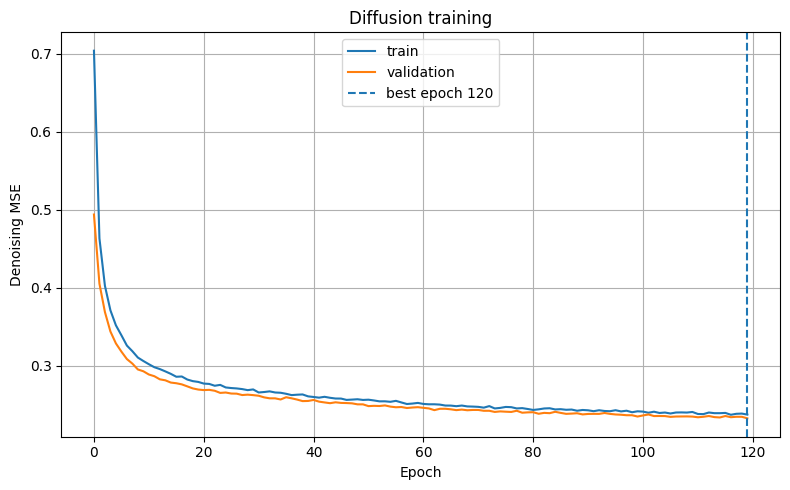

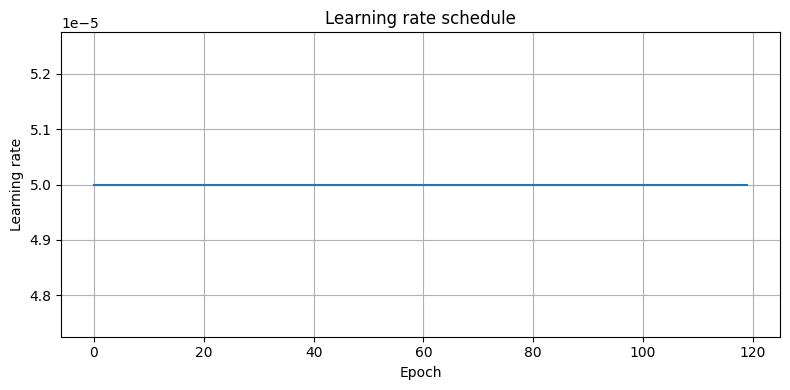

In [33]:
plt.figure(figsize=(8, 5))
plt.plot(train_history, label="train")
plt.plot(val_history, label="validation")
plt.axvline(best_epoch - 1, linestyle="--", label=f"best epoch {best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("Denoising MSE")
plt.title("Diffusion training")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "diffusion_training_curve.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(lr_history)
plt.xlabel("Epoch")
plt.ylabel("Learning rate")
plt.title("Learning rate schedule")
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "diffusion_lr_schedule.png", dpi=200)
plt.show()

## 11. Denoising scores per timestep


In questa fase non stiamo più allenando il modello, ma lo usiamo per costruire uno **score di anomalia** per ogni jet.

Il diffusion model è stato allenato a predire il rumore aggiunto a jet QCD. Per questo motivo, se un evento è simile al QCD, il modello dovrebbe riuscire a predire bene il rumore; se invece l’evento è anomalo, ad esempio più simile a un Emerging Jet, l’errore di predizione tende ad aumentare.

Calcoliamo questo errore a diversi timestep del processo di diffusione, cioè a diversi livelli di rumore. Gli step bassi corrispondono a poco rumore, quelli alti a molto rumore. Usiamo più timestep perché alcune anomalie possono essere più visibili a livelli intermedi o alti di rumore.

Per rendere lo score più stabile, ripetiamo il calcolo più volte con rumori casuali diversi e poi facciamo la media.

In [34]:
# Timestep scelti sulla base dei run precedenti:
# low spesso debole, mid e mid+high spesso più informativi.

timesteps_all = torch.tensor([5, 10, 20, 40, 70, 100, 140, 180], dtype=torch.long, device=device)
timesteps_low = torch.tensor([5, 10, 20], dtype=torch.long, device=device)
timesteps_mid = torch.tensor([40, 70, 100], dtype=torch.long, device=device)
timesteps_high = torch.tensor([140, 180], dtype=torch.long, device=device)
timesteps_mid_high = torch.tensor([40, 70, 100, 140, 180], dtype=torch.long, device=device)

print("timesteps_all:", timesteps_all.cpu().numpy())


def compute_per_timestep_scores(model, X, timesteps, batch_size=2048, n_noise_repeats=3):
    loader = DataLoader(
        DiffusionDataset(X),
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    model.eval()
    all_scores = []

    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            B = X_batch.shape[0]

            scores_batch = []

            for t_scalar in timesteps:
                t = torch.full((B,), int(t_scalar.item()), device=device, dtype=torch.long)

                score_sum = torch.zeros(B, device=device)

                for _ in range(n_noise_repeats):
                    noise = torch.randn_like(X_batch)
                    xt, true_noise = q_sample(X_batch, t, noise=noise)
                    pred_noise = model(xt, t)

                    mse = torch.mean((pred_noise - true_noise) ** 2, dim=1)
                    score_sum += mse

                score_t = score_sum / n_noise_repeats
                scores_batch.append(score_t.unsqueeze(1))

            scores_batch = torch.cat(scores_batch, dim=1)
            all_scores.append(scores_batch.cpu().numpy())

    return np.concatenate(all_scores, axis=0)


N_NOISE_REPEATS = 3
# Calcolo gli score diffusion per train, validation, background e segnale.
train_scores_t = compute_per_timestep_scores(model, X_train, timesteps_all, n_noise_repeats=N_NOISE_REPEATS)
val_scores_t = compute_per_timestep_scores(model, X_val, timesteps_all, n_noise_repeats=N_NOISE_REPEATS)
bkg_test_scores_t = compute_per_timestep_scores(model, X_bkg_test, timesteps_all, n_noise_repeats=N_NOISE_REPEATS)
sig_scores_t = compute_per_timestep_scores(model, X_sig, timesteps_all, n_noise_repeats=N_NOISE_REPEATS)

print("train_scores_t:", train_scores_t.shape)
print("val_scores_t:", val_scores_t.shape)
print("bkg_test_scores_t:", bkg_test_scores_t.shape)
print("sig_scores_t:", sig_scores_t.shape)

timesteps_all: [  5  10  20  40  70 100 140 180]
train_scores_t: (100000, 8)
val_scores_t: (100000, 8)
bkg_test_scores_t: (100000, 8)
sig_scores_t: (61966, 8)


## 12. Costruzione score raw e z-normalized


Dopo aver calcolato l’errore del diffusion model per diversi timestep, combiniamo questi valori in score più semplici da confrontare.

Creiamo score medi usando gruppi diversi di timestep: bassi, medi, alti, oppure tutti insieme. Questo serve perché l’anomalia può essere più visibile a certi livelli di rumore e non necessariamente su tutto il processo di diffusione.

Oltre agli score grezzi, costruiamo anche score standardizzati rispetto al training QCD. In questo modo ogni timestep viene messo sulla stessa scala prima di fare la media.

In [35]:
# Indici rispetto a timesteps_all = [5, 10, 20, 40, 70, 100, 140, 180]
IDX_LOW = [0, 1, 2]
IDX_MID = [3, 4, 5]
IDX_HIGH = [6, 7]
IDX_MID_HIGH = [3, 4, 5, 6, 7]


def make_score_dict(scores_t, train_mean=None, train_std=None):
    # Score grezzi: media dell'errore DDPM su diversi gruppi di timestep
    raw = {
        "raw_all": scores_t.mean(axis=1),
        "raw_low": scores_t[:, IDX_LOW].mean(axis=1),
        "raw_mid": scores_t[:, IDX_MID].mean(axis=1),
        "raw_high": scores_t[:, IDX_HIGH].mean(axis=1),
        "raw_mid_high": scores_t[:, IDX_MID_HIGH].mean(axis=1),
    }

    out = dict(raw)
 # Se passo media e deviazione standard del training QCD costruisco anche score normalizzati per timestep
    if train_mean is not None and train_std is not None:
        z = (scores_t - train_mean) / train_std
        out.update({
            "z_all": z.mean(axis=1),
            "z_low": z[:, IDX_LOW].mean(axis=1),
            "z_mid": z[:, IDX_MID].mean(axis=1),
            "z_high": z[:, IDX_HIGH].mean(axis=1),
            "z_mid_high": z[:, IDX_MID_HIGH].mean(axis=1),
        })

    return out


train_t_mean = train_scores_t.mean(axis=0, keepdims=True)
train_t_std = np.maximum(train_scores_t.std(axis=0, keepdims=True), 1e-8)

# Creo tutte le varianti di score per train, validation, background e segnale
scores_train = make_score_dict(train_scores_t, train_t_mean, train_t_std)
scores_val = make_score_dict(val_scores_t, train_t_mean, train_t_std)
scores_bkg_test = make_score_dict(bkg_test_scores_t, train_t_mean, train_t_std)
scores_sig = make_score_dict(sig_scores_t, train_t_mean, train_t_std)

print("Available score variants:")
print(list(scores_train.keys()))


def print_summary(name, scores):
    print("\n", name)
    print("mean:", float(np.mean(scores)))
    print("std:", float(np.std(scores)))
    print("median:", float(np.median(scores)))
    print("quantiles:", np.percentile(scores, [0, 1, 5, 25, 50, 75, 95, 99, 99.9, 100]))


print_summary("bkg_test z_all", scores_bkg_test["z_all"])
print_summary("signal z_all", scores_sig["z_all"])

Available score variants:
['raw_all', 'raw_low', 'raw_mid', 'raw_high', 'raw_mid_high', 'z_all', 'z_low', 'z_mid', 'z_high', 'z_mid_high']

 bkg_test z_all
mean: 0.0151992067694664
std: 0.6179195642471313
median: -0.04287238419055939
quantiles: [-1.90179229 -1.14569512 -0.85867811 -0.40029484 -0.04287238  0.36483148
  1.06778302  1.72286478  2.80044306 20.59797859]

 signal z_all
mean: 1.3838602304458618
std: 1.7743446826934814
median: 1.1492522954940796
quantiles: [-1.67154098 -0.55611351 -0.11033333  0.59309773  1.1492523   1.82166913
  3.25283635  5.05071807 23.92015987 28.5183773 ]


## 13. Metriche e scelta score migliore

Qui confrontiamo le diverse definizioni di anomaly score ottenute dal diffusion model.

Per ogni score calcoliamo la curva ROC e l’AUC, usando QCD come background e Emerging Jets come segnale. Siccome non è garantito che uno score alto significhi automaticamente “più anomalo”, controlliamo anche lo score invertito. Se l’inversione dà AUC migliore, cambiamo segno allo score.

Infine, per lo score migliore, calcoliamo l’efficienza del segnale a diversi mistag rate del background.

In [36]:
def orient_scores(bg, sig):
    # Creo le label: 0 = background QCD, 1 = segnale
    y = np.concatenate([np.zeros_like(bg), np.ones_like(sig)])
    s = np.concatenate([bg, sig])

    auc = roc_auc_score(y, s)
    auc_inv = roc_auc_score(y, -s)

    if auc_inv > auc:
        return -bg, -sig, auc_inv, True, auc, auc_inv
    return bg, sig, auc, False, auc, auc_inv


def evaluate_scores(bg, sig, model_name="Diffusion", score_name="score"):
    bg_o, sig_o, best_auc, flipped, auc, auc_inv = orient_scores(bg, sig)

    y = np.concatenate([np.zeros_like(bg_o), np.ones_like(sig_o)])
    s = np.concatenate([bg_o, sig_o])
# Calcolo la curva ROC per lo score orientato
    fpr, tpr, thresholds = roc_curve(y, s)

    rows = []
# Calcolo l'efficienza del segnale a vari livelli di mistag del background
    for mistag in [0.30, 0.10, 0.05, 0.01, 0.001]:
        threshold = np.quantile(bg_o, 1.0 - mistag)
        eff = np.mean(sig_o >= threshold)
        actual_mistag = np.mean(bg_o >= threshold)

        rows.append({
            "model": model_name,
            "score": score_name,
            "auc": best_auc,
            "raw_auc": auc,
            "auc_inverted": auc_inv,
            "flipped": flipped,
            "mistag_target": mistag,
            "actual_mistag": actual_mistag,
            "signal_efficiency": eff,
            "threshold": threshold,
        })

    return {
        "bg_oriented": bg_o,
        "sig_oriented": sig_o,
        "best_auc": best_auc,
        "auc": auc,
        "auc_inverted": auc_inv,
        "flipped": flipped,
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds,
        "eff_table": pd.DataFrame(rows),
    }


evals = {}
rows = []

for score_name in scores_bkg_test.keys():
    ev = evaluate_scores(
        scores_bkg_test[score_name],
        scores_sig[score_name],
        model_name="Diffusion",
        score_name=score_name,
    )
    evals[score_name] = ev

    rows.append({
        "model": "Diffusion",
        "score": score_name,
        "auc": ev["auc"],
        "auc_inverted": ev["auc_inverted"],
        "best_auc": ev["best_auc"],
        "flipped": ev["flipped"],
    })
# Tabella riassuntiva ordinata per AUC migliore
df_score_comparison = pd.DataFrame(rows).sort_values("best_auc", ascending=False).reset_index(drop=True)
display(df_score_comparison)

best_score_name = df_score_comparison.iloc[0]["score"]
best_eval = evals[best_score_name]

print("Best score:", best_score_name)
print("Best AUC:", best_eval["best_auc"])
# Mostro l'efficienza del segnale a diversi mistag rate per lo score migliore
display(best_eval["eff_table"])

,model,score,auc,auc_inverted,best_auc,flipped
0,Diffusion,raw_all,0.877423,0.122577,0.877423,False
1,Diffusion,z_all,0.877009,0.122991,0.877009,False
2,Diffusion,raw_mid_high,0.856396,0.143604,0.856396,False
3,Diffusion,z_mid_high,0.854867,0.145133,0.854867,False
4,Diffusion,raw_mid,0.846159,0.153841,0.846159,False
5,Diffusion,z_mid,0.845942,0.154058,0.845942,False
6,Diffusion,z_low,0.821879,0.178121,0.821879,False
7,Diffusion,raw_low,0.820034,0.179966,0.820034,False
8,Diffusion,z_high,0.813530,0.186470,0.813530,False
9,Diffusion,raw_high,0.813437,0.186563,0.813437,False


Best score: raw_all
Best AUC: 0.8774231156602006


,model,score,auc,raw_auc,auc_inverted,flipped,mistag_target,actual_mistag,signal_efficiency,threshold
0,Diffusion,raw_all,0.877423,0.877423,0.122577,False,0.300,0.300,0.865152,0.466472
1,Diffusion,raw_all,0.877423,0.877423,0.122577,False,0.100,0.100,0.669851,0.493617
2,Diffusion,raw_all,0.877423,0.877423,0.122577,False,0.050,0.050,0.542314,0.508378
3,Diffusion,raw_all,0.877423,0.877423,0.122577,False,0.010,0.010,0.288755,0.541091
4,Diffusion,raw_all,0.877423,0.877423,0.122577,False,0.001,0.001,0.083820,0.595322


## 14. Background checks

Dopo aver scelto lo score migliore, controlliamo che non stia separando artificialmente i diversi campioni QCD tra loro.

Confrontiamo quindi train QCD, validation QCD e test QCD usando l’AUC. Idealmente questi campioni dovrebbero essere poco distinguibili, quindi un valore vicino a 0.5 indica buona consistenza. Se invece l’AUC è molto alta, potrebbe esserci una differenza di distribuzione tra i campioni o un problema nel preprocessing.

In [37]:
#controlliamo che su quelli di background otteniamo auc di 0.5
def bg_vs_bg_auc(a, b, name_a, name_b):
    y = np.concatenate([np.zeros_like(a), np.ones_like(b)])
    s = np.concatenate([a, b])

    auc = roc_auc_score(y, s)
    auc_inv = roc_auc_score(y, -s)

    return {
        "comparison": f"{name_a} vs {name_b}",
        "auc": auc,
        "auc_inverted": auc_inv,
        "best_auc": max(auc, auc_inv),
    }


bg_checks = pd.DataFrame([
    bg_vs_bg_auc(scores_train[best_score_name], scores_val[best_score_name], "train QCD", "val QCD"),
    bg_vs_bg_auc(scores_train[best_score_name], scores_bkg_test[best_score_name], "train QCD", "test QCD"),
    bg_vs_bg_auc(scores_val[best_score_name], scores_bkg_test[best_score_name], "val QCD", "test QCD"),
])

display(bg_checks)

,comparison,auc,auc_inverted,best_auc
0,train QCD vs val QCD,0.508145,0.491855,0.508145
1,train QCD vs test QCD,0.507369,0.492631,0.507369
2,val QCD vs test QCD,0.499225,0.500775,0.500775


## 15. Plot ROC, score distribution, efficiency vs mistag

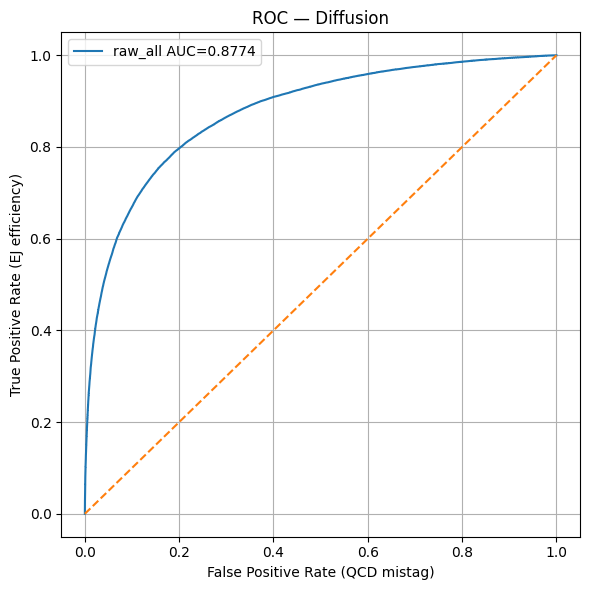

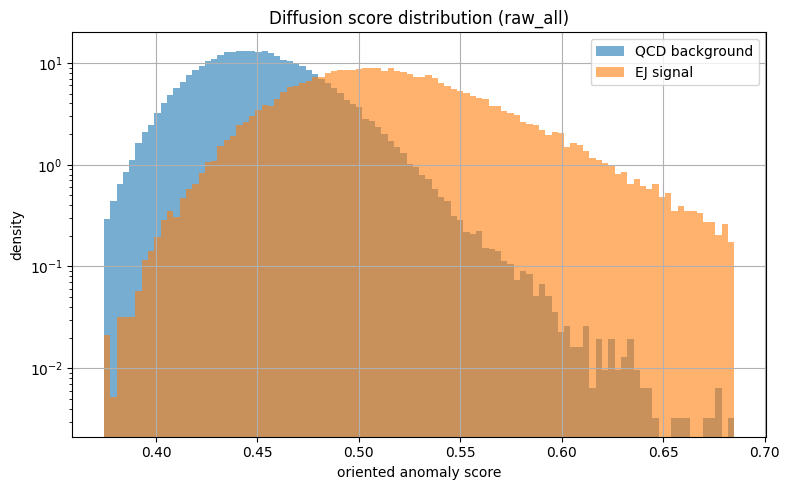

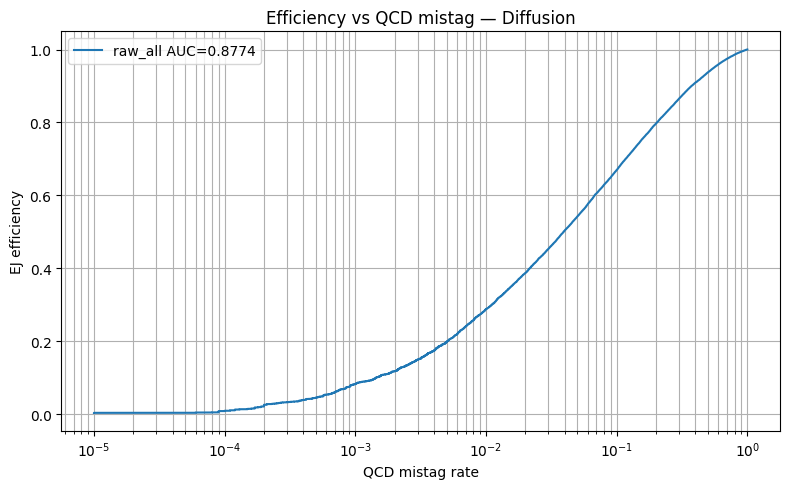

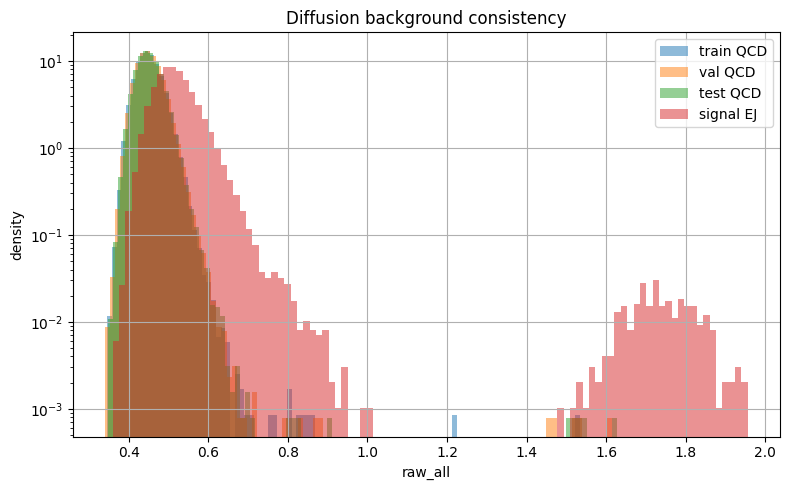

In [38]:
bg_o = best_eval["bg_oriented"]
sig_o = best_eval["sig_oriented"]

plt.figure(figsize=(6, 6))
plt.plot(best_eval["fpr"], best_eval["tpr"], label=f"{best_score_name} AUC={best_eval['best_auc']:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate (QCD mistag)")
plt.ylabel("True Positive Rate (EJ efficiency)")
plt.title("ROC — Diffusion")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "diffusion_roc.png", dpi=200)
plt.show()

all_scores = np.concatenate([bg_o, sig_o])
lo = np.percentile(all_scores, 0.1)
hi = np.percentile(all_scores, 99.5)

plt.figure(figsize=(8, 5))
plt.hist(bg_o, bins=100, range=(lo, hi), density=True, alpha=0.6, label="QCD background")
plt.hist(sig_o, bins=100, range=(lo, hi), density=True, alpha=0.6, label="EJ signal")
plt.yscale("log")
plt.xlabel("oriented anomaly score")
plt.ylabel("density")
plt.title(f"Diffusion score distribution ({best_score_name})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "diffusion_score_distribution.png", dpi=200)
plt.show()

fpr = best_eval["fpr"]
tpr = best_eval["tpr"]
mask = fpr > 0

plt.figure(figsize=(8, 5))
plt.plot(fpr[mask], tpr[mask], label=f"{best_score_name} AUC={best_eval['best_auc']:.4f}")
plt.xscale("log")
plt.xlabel("QCD mistag rate")
plt.ylabel("EJ efficiency")
plt.title("Efficiency vs QCD mistag — Diffusion")
plt.legend()
plt.grid(True, which="both")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "diffusion_efficiency_vs_mistag.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(scores_train[best_score_name], bins=100, density=True, alpha=0.5, label="train QCD")
plt.hist(scores_val[best_score_name], bins=100, density=True, alpha=0.5, label="val QCD")
plt.hist(scores_bkg_test[best_score_name], bins=100, density=True, alpha=0.5, label="test QCD")
plt.hist(scores_sig[best_score_name], bins=100, density=True, alpha=0.5, label="signal EJ")
plt.yscale("log")
plt.xlabel(best_score_name)
plt.ylabel("density")
plt.title("Diffusion background consistency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "diffusion_background_consistency.png", dpi=200)
plt.show()

## 16. AUC per timestep

,timestep,auc,auc_inverted,best_auc,flipped
0,5,0.701894,0.298106,0.701894,False
1,10,0.738043,0.261957,0.738043,False
2,20,0.771347,0.228653,0.771347,False
3,40,0.794086,0.205914,0.794086,False
4,70,0.799768,0.200232,0.799768,False
5,100,0.795738,0.204262,0.795738,False
6,140,0.791728,0.208272,0.791728,False
7,180,0.790229,0.209771,0.790229,False


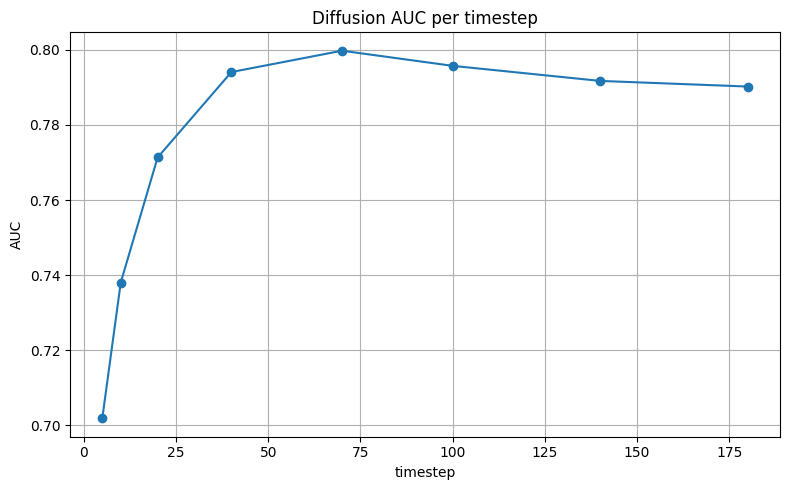

In [39]:
per_timestep_rows = []

for i, t in enumerate(timesteps_all.cpu().numpy().tolist()):
    ev_t = evaluate_scores(
        bkg_test_scores_t[:, i],
        sig_scores_t[:, i],
        model_name="Diffusion",
        score_name=f"t={t}",
    )
    per_timestep_rows.append({
        "timestep": t,
        "auc": ev_t["auc"],
        "auc_inverted": ev_t["auc_inverted"],
        "best_auc": ev_t["best_auc"],
        "flipped": ev_t["flipped"],
    })

df_per_timestep = pd.DataFrame(per_timestep_rows)
display(df_per_timestep)

plt.figure(figsize=(8, 5))
plt.plot(df_per_timestep["timestep"], df_per_timestep["best_auc"], marker="o")
plt.xlabel("timestep")
plt.ylabel("AUC")
plt.title("Diffusion AUC per timestep")
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "diffusion_auc_per_timestep.png", dpi=200)
plt.show()

## 18. Salvataggio finale

In [40]:
results_summary = {
    "model": "Diffusion",
    "best_score": str(best_score_name),
    "auc": float(best_eval["auc"]),
    "auc_inverted": float(best_eval["auc_inverted"]),
    "best_auc": float(best_eval["best_auc"]),
    "flipped": bool(best_eval["flipped"]),
    "input_dim": int(input_dim),
    "T": int(T),
    "beta_start": float(BETA_START),
    "beta_end": float(BETA_END),
    "time_emb_dim": int(TIME_EMB_DIM),
    "hidden_dim": int(HIDDEN_DIM),
    "n_blocks": int(N_BLOCKS),
    "dropout": float(DROPOUT),
    "learning_rate": float(LR),
    "weight_decay": float(WEIGHT_DECAY),
    "batch_size": int(BATCH_SIZE),
    "hparam_tuning_used": bool("diffusion_tuning_results_df" in globals()),
    "hparam_selection_score": float(BEST_DIFFUSION_CONFIG.get("selection_score", np.nan)) if "BEST_DIFFUSION_CONFIG" in globals() else float("nan"),
    "best_epoch": int(best_epoch),
    "best_val_loss": float(best_val),
    "clip_value": float(CLIP_VALUE),
    "n_noise_repeats": int(N_NOISE_REPEATS),
}

for _, row in bg_checks.iterrows():
    key = row["comparison"].replace(" ", "_").replace("vs", "VS")
    results_summary[f"{key}_best_auc"] = float(row["best_auc"])

with open(OUTPUT_DIR / "diffusion_config.json", "w") as f:
    json.dump(
        {
            **results_summary,
            "aggregate_feature_names": aggregate_feature_names,
            "processed_path": str(PROCESSED_PATH),
            "scaler": scaler.state_dict(),
            "timesteps_all": timesteps_all.cpu().numpy().tolist(),
            "train_t_mean": train_t_mean.reshape(-1).tolist(),
            "train_t_std": train_t_std.reshape(-1).tolist(),
        },
        f,
        indent=2,
    )

best_eval["eff_table"].to_csv(OUTPUT_DIR / "diffusion_results.csv", index=False)
df_score_comparison.to_csv(OUTPUT_DIR / "diffusion_score_comparison.csv", index=False)
df_per_timestep.to_csv(OUTPUT_DIR / "diffusion_auc_per_timestep.csv", index=False)
bg_checks.to_csv(OUTPUT_DIR / "diffusion_background_checks.csv", index=False)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "config": results_summary,
        "aggregate_feature_names": aggregate_feature_names,
        "scaler": scaler.state_dict(),
        "train_history": train_history,
        "val_history": val_history,
    },
    OUTPUT_DIR / "diffusion_model.pt",
)

np.savez_compressed(
    OUTPUT_DIR / "diffusion_scores.npz",
    train_scores_t=train_scores_t,
    val_scores_t=val_scores_t,
    bkg_test_scores_t=bkg_test_scores_t,
    sig_scores_t=sig_scores_t,
    timesteps_all=timesteps_all.cpu().numpy(),
    train_t_mean=train_t_mean,
    train_t_std=train_t_std,
    scores_train_raw_all=scores_train["raw_all"],
    scores_val_raw_all=scores_val["raw_all"],
    scores_bkg_test_raw_all=scores_bkg_test["raw_all"],
    scores_sig_raw_all=scores_sig["raw_all"],
    scores_train_z_all=scores_train["z_all"],
    scores_val_z_all=scores_val["z_all"],
    scores_bkg_test_z_all=scores_bkg_test["z_all"],
    scores_sig_z_all=scores_sig["z_all"],
    scores_train_z_mid=scores_train["z_mid"],
    scores_val_z_mid=scores_val["z_mid"],
    scores_bkg_test_z_mid=scores_bkg_test["z_mid"],
    scores_sig_z_mid=scores_sig["z_mid"],
    scores_train_z_mid_high=scores_train["z_mid_high"],
    scores_val_z_mid_high=scores_val["z_mid_high"],
    scores_bkg_test_z_mid_high=scores_bkg_test["z_mid_high"],
    scores_sig_z_mid_high=scores_sig["z_mid_high"],
    best_score_name=np.array(best_score_name, dtype=object),
    best_bg_oriented=best_eval["bg_oriented"],
    best_sig_oriented=best_eval["sig_oriented"],
    fpr=best_eval["fpr"],
    tpr=best_eval["tpr"],
    thresholds=best_eval["thresholds"],
    aggregate_feature_names=np.array(aggregate_feature_names, dtype=object),
    auc=np.array(best_eval["auc"], dtype=np.float32),
    auc_inverted=np.array(best_eval["auc_inverted"], dtype=np.float32),
    best_auc=np.array(best_eval["best_auc"], dtype=np.float32),
)

print("Saved:")
print(OUTPUT_DIR / "diffusion_model.pt")
print(OUTPUT_DIR / "diffusion_scores.npz")
print(OUTPUT_DIR / "diffusion_results.csv")
print(OUTPUT_DIR / "diffusion_score_comparison.csv")
print(OUTPUT_DIR / "diffusion_auc_per_timestep.csv")
print(OUTPUT_DIR / "diffusion_background_checks.csv")
print(OUTPUT_DIR / "diffusion_config.json")
print("plots:", PLOTS_DIR)

Saved:
..\outputs\diffusion\diffusion_model.pt
..\outputs\diffusion\diffusion_scores.npz
..\outputs\diffusion\diffusion_results.csv
..\outputs\diffusion\diffusion_score_comparison.csv
..\outputs\diffusion\diffusion_auc_per_timestep.csv
..\outputs\diffusion\diffusion_background_checks.csv
..\outputs\diffusion\diffusion_config.json
plots: ..\outputs\diffusion\plots
